In [1]:
# Imports
import os
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# Configuration - Le dataset est dans le dossier courant
DATASET_PATH = './Dataset'

## 📊 Informations sur le Dataset

In [4]:
# Vérifier que le dossier existe
if not os.path.exists(DATASET_PATH):
    print(f"❌ Erreur: Le dossier n'existe pas: {DATASET_PATH}")
else:
    print(f"✅ Dossier trouvé: {DATASET_PATH}")

✅ Dossier trouvé: ./Dataset


In [5]:
# Lister les classes (dossiers)
classes = [nom for nom in os.listdir(DATASET_PATH) 
           if os.path.isdir(os.path.join(DATASET_PATH, nom))]
classes.sort()

print(f"📊 Nombre de classes: {len(classes)}")

📊 Nombre de classes: 23


In [6]:
# Compter les images par classe
print("📋 LISTE DES CLASSES:")
print("-" * 50)

total_images = 0
for classe in classes:
    chemin_classe = os.path.join(DATASET_PATH, classe)
    # Compter les images (jpg, png, jpeg)
    images = [f for f in os.listdir(chemin_classe) 
              if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    nb_images = len(images)
    total_images += nb_images
    print(f"  • {classe}: {nb_images} images")

print("-" * 50)
print(f"📷 TOTAL: {total_images} images")
print(f"📈 Moyenne par classe: {total_images // len(classes)} images")

📋 LISTE DES CLASSES:
--------------------------------------------------
  • Apple___Apple_scab: 2016 images
  • Apple___Black_rot: 1987 images
  • Apple___Cedar_apple_rust: 1760 images
  • Apple___healthy: 2008 images
  • Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642 images
  • Corn_(maize)___Common_rust_: 1907 images
  • Corn_(maize)___Northern_Leaf_Blight: 1908 images
  • Corn_(maize)___healthy: 1859 images
  • Pepper__bell___Bacterial_spot: 997 images
  • Pepper__bell___healthy: 1478 images
  • Potato___Early_blight: 1000 images
  • Potato___Late_blight: 1000 images
  • Potato___healthy: 152 images
  • Tomato_Bacterial_spot: 2127 images
  • Tomato_Early_blight: 1000 images
  • Tomato_Late_blight: 1909 images
  • Tomato_Leaf_Mold: 952 images
  • Tomato_Septoria_leaf_spot: 1771 images
  • Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
  • Tomato__Target_Spot: 1404 images
  • Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
  • Tomato__Tomato_mosaic_virus: 373 im

## 🖼️ Affichage d'une image par classe

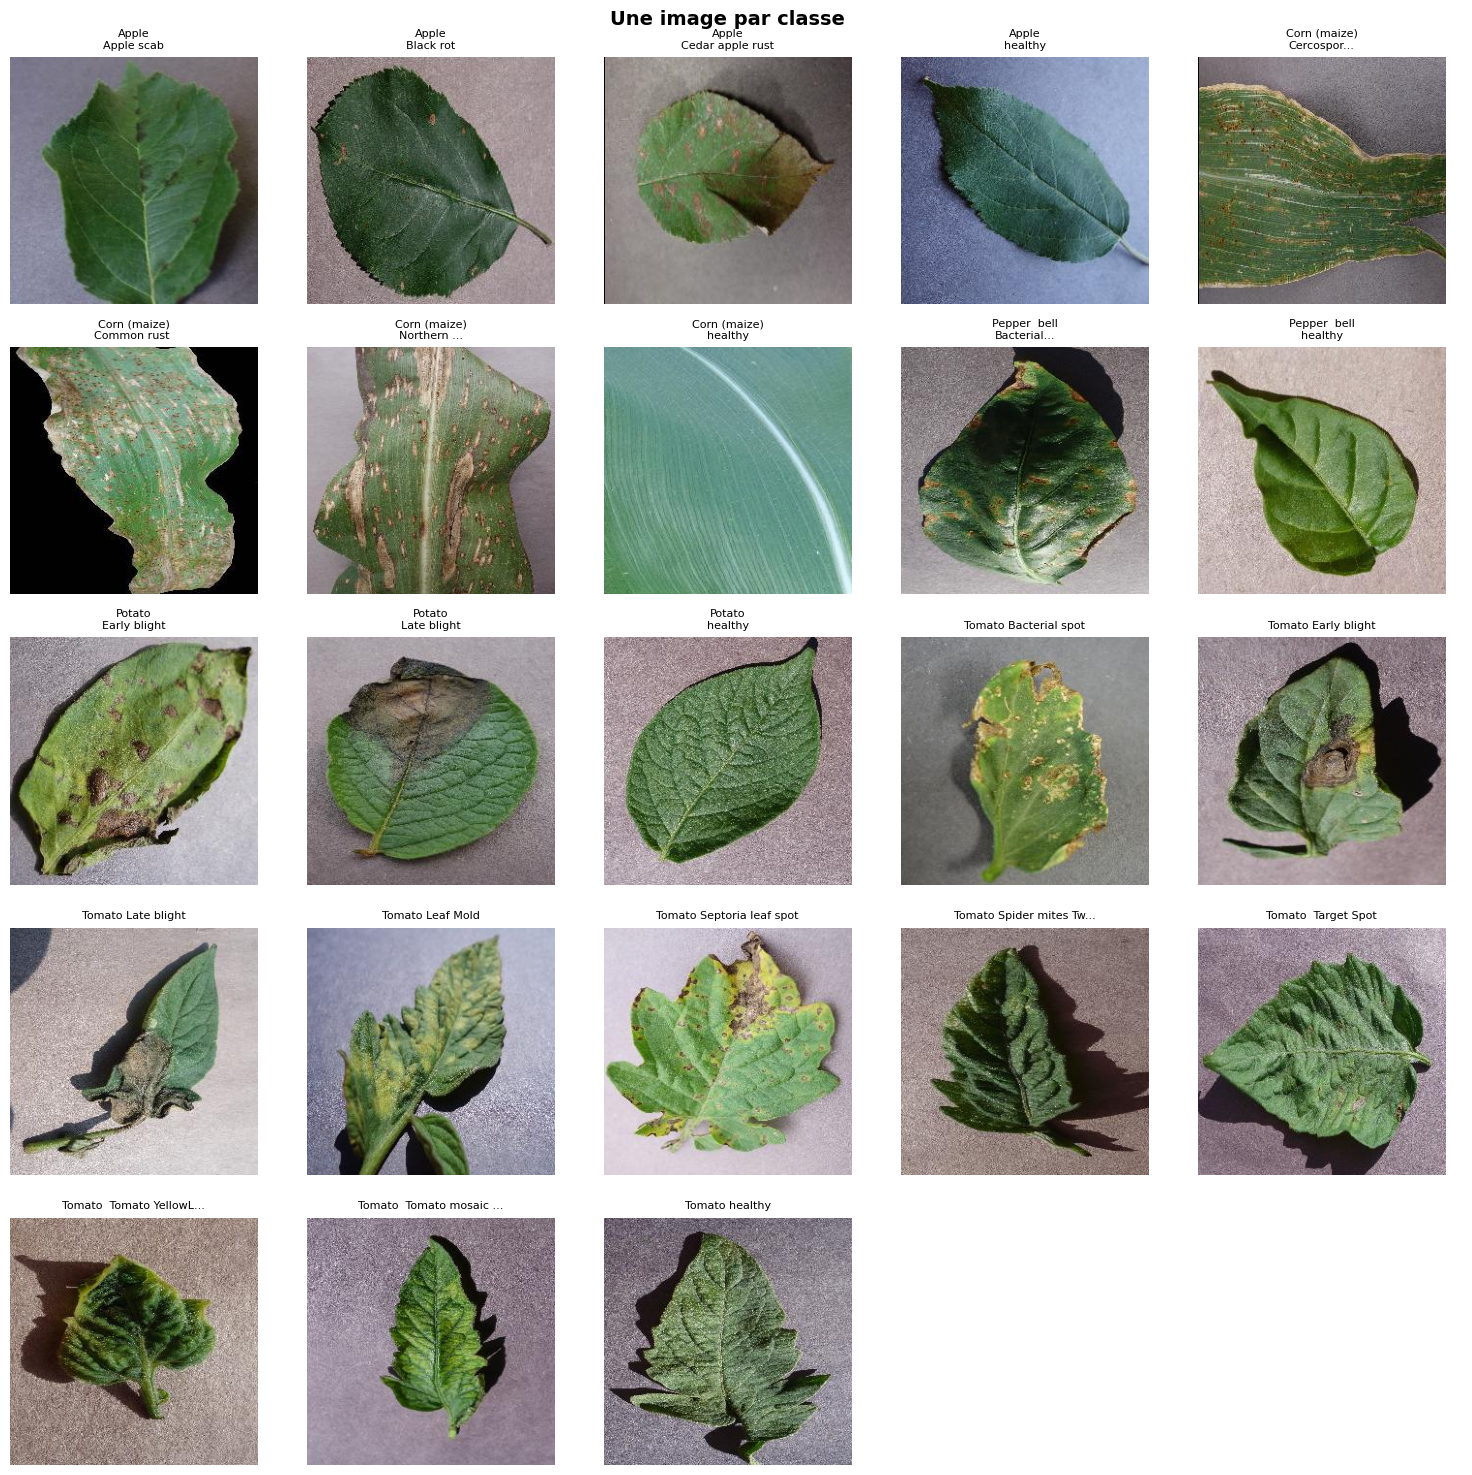

In [7]:
# Calculer la grille
n_classes = len(classes)
n_cols = 5
n_rows = (n_classes + n_cols - 1) // n_cols

# Créer la figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten()

for i, classe in enumerate(classes):
    chemin_classe = os.path.join(DATASET_PATH, classe)
    
    # Trouver la première image
    images = [f for f in os.listdir(chemin_classe) 
              if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    if images:
        chemin_image = os.path.join(chemin_classe, images[0])
        with Image.open(chemin_image) as img:
            axes[i].imshow(img)
            # Raccourcir le nom pour l'affichage
            nom_court = classe.replace('___', '\n').replace('_', ' ')
            if len(nom_court) > 25:
                nom_court = nom_court[:22] + '...'
            axes[i].set_title(nom_court, fontsize=8)
    
    axes[i].axis('off')

# Cacher les axes vides
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Une image par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ✅ Exploration terminée!